# Phase 2: Content-based filtering

Goal: describe each movie by what it *is* (genres, tags, decade), describe each user by the kind of movies they rate highly, and recommend by matching the two. Model code is in `training/recsys/content.py`. By the end you should be able to answer:

1. What does a movie look like as a vector? Which of its tokens carry the most weight, and why?
2. Do content-based "similar movies" make sense? Where do they go wrong?
3. What does a user's taste profile look like?
4. Can content alone beat "show everyone the most popular movies"? Why or why not?
5. What happens when you mix popularity in?
6. What can a content model do that the phase 1 baselines can't?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().resolve().parent))
from recsys.baselines import BiasModel, Popularity
from recsys.content import ContentModel
from recsys.data import drop_pairs, load_movies, load_ratings, load_tags, time_split
from recsys.evaluate import evaluate, top_k

ratings = load_ratings()
movies = load_movies()
tags = load_tags()
train, val, test = time_split(ratings)
titles = movies.set_index("movieId")["title"]
train_counts = train.groupby("movieId").size()


def find(text: str) -> int:
    """movieId of the first title containing `text` (case-insensitive)."""
    hits = movies[movies["title"].str.contains(text, case=False, regex=False)]
    if hits.empty:
        raise KeyError(f"no title contains {text!r}")
    return int(hits["movieId"].iloc[0])


def with_titles(s: pd.Series) -> pd.DataFrame:
    """Attach titles and train rating counts to a movieId-indexed Series."""
    df = s.to_frame()
    df["title"] = titles.reindex(df.index).to_numpy()
    df["n_ratings"] = train_counts.reindex(df.index, fill_value=0).to_numpy()
    return df

## 1. Tags, and a subtle leak

`tags.csv` holds free-text labels users attached to movies ("pixar", "time travel", "twist ending"). Someone who tagged a movie has seen it. If user 42 tagged *Inception* and *Inception* is in user 42's val or test ratings, keeping that tag would leak a trace of the held-out answer into the movie features.

`drop_pairs` removes tags whose (user, movie) pair is in a held-out set. It's a small effect here, but this habit of asking "what does this feature know that the model shouldn't?" matters in every phase.

In [2]:
tags_train = drop_pairs(tags, val, test)
print(f"tags: {len(tags):,} total, {len(tags_train):,} kept for training")
print(f"movies with any tag: {movies['movieId'].isin(tags_train['movieId']).mean():.1%} of the catalog")

tags: 3,683 total, 2,868 kept for training
movies with any tag: 13.1% of the catalog


## 2. Movies as vectors (TF-IDF)

Each movie becomes a vector with one dimension per token: `genre:Comedy`, `tag:pixar`, `decade:1990s`, …

```
weight(movie, token) = tf × idf × field_weight
    tf  = 1 + log(count)                  how strongly the token applies (a tag applied 10× counts more than 1×, but not 10× more)
    idf = log((1 + N) / (1 + df)) + 1     N = number of movies, df = movies having the token
```

**IDF** (inverse document frequency) is the key idea: a token that appears on almost every movie (`genre:Drama`) tells you little about any one of them, so it gets a low weight. A rare token (`tag:pixar`) is very informative.

Each vector is then scaled to length 1, so the dot product of two movie vectors equals their **cosine similarity**: 1 = same direction (same content), 0 = nothing in common.

The terms come from text search: "document" = movie, "term" = token. Search engines ranked documents this way long before recommender systems did.

In [3]:
model = ContentModel().fit(train, movies, tags_train)

field = model.vocab.str.split(":").str[0]
print(f"matrix: {model.X.shape[0]:,} movies × {model.X.shape[1]} tokens, {model.X.nnz:,} non-zeros "
      f"({model.X.nnz / np.prod(model.X.shape):.2%} filled)")
print("tokens per field:", field.value_counts().to_dict())

movies_per_token = pd.Series(np.asarray((model.X != 0).sum(axis=0)).ravel(), index=model.vocab)
print("\nmost common tokens (lowest idf):")
print(movies_per_token.sort_values(ascending=False).head(6).to_string())

matrix: 9,742 movies × 475 tokens, 33,819 non-zeros (0.73% filled)
tokens per field: {'tag': 444, 'genre': 19, 'decade': 12}

most common tokens (lowest idf):
genre:Drama       4361
genre:Comedy      3756
decade:2000s      2849
decade:1990s      2212
decade:2010s      1931
genre:Thriller    1894


In [4]:
# The biggest weights in two movies' vectors. Rare tags dominate; common genres sit near the bottom.
pd.concat(
    {t: model.movie_vector(find(t)).round(3).reset_index() for t in ["Toy Story (1995)", "Matrix, The (1999)"]},
    axis=1,
)

Toy Story (1995)             Matrix, The (1999)       
             index weight                   index weight
0        tag:pixar  0.792  tag:alternate universe  0.471
1          tag:fun  0.458    tag:post apocalyptic  0.444
2  genre:Animation  0.206          tag:philosophy  0.435
3   genre:Children  0.201        tag:martial arts  0.414
4    genre:Fantasy  0.192              tag:sci-fi  0.387
5  genre:Adventure  0.166            genre:Sci-Fi  0.171
6     genre:Comedy  0.107            genre:Action  0.138
7     decade:1990s  0.068          genre:Thriller  0.137
8              NaN    NaN            decade:1990s  0.064

## 3. Similar movies

`similar(movie_id)` is one matrix-vector product: the cosine similarity of one movie against every other movie. This is what the `GET /movies/{id}/similar` endpoint will serve.

In [5]:
for t in ["Toy Story (1995)", "Matrix, The (1999)", "Shawshank Redemption"]:
    print(t)
    display(with_titles(model.similar(find(t), 8).round(3)))

Toy Story (1995)


,similarity,title,n_ratings
movieId,,,
3114,0.863,Toy Story 2 (1999),85
2355,0.846,"Bug's Life, A (1998)",79
122918,0.436,Guardians of the Galaxy 2 (2017),17
2294,0.404,Antz (1998),36
3754,0.394,"Adventures of Rocky and Bullwinkle, The (2000)",8
4016,0.394,"Emperor's New Groove, The (2000)",33
91355,0.394,Asterix and the Vikings (Astérix et les Viking...,0
65577,0.394,"Tale of Despereaux, The (2008)",1


Matrix, The (1999)


,similarity,title,n_ratings
movieId,,,
1726,0.469,"Postman, The (1997)",10
1680,0.446,Sliding Doors (1998),23
8983,0.403,House of Flying Daggers (Shi mian mai fu) (2004),23
7090,0.399,Hero (Ying xiong) (2002),31
2421,0.397,"Karate Kid, Part II, The (1986)",22
2420,0.396,"Karate Kid, The (1984)",28
2422,0.368,"Karate Kid, Part III, The (1989)",13
3527,0.352,Predator (1987),52


Shawshank Redemption


,similarity,title,n_ratings
movieId,,,
280,0.572,Murder in the First (1995),8
3147,0.555,"Green Mile, The (1999)",90
230,0.490,Dolores Claiborne (1995),19
1259,0.467,Stand by Me (1986),76
2118,0.460,"Dead Zone, The (1983)",13
2787,0.447,Cat's Eye (1985),6
2517,0.447,Christine (1983),9
2122,0.426,Children of the Corn (1984),8


In [6]:
# Why are two movies similar? Each token contributes (weight in A) × (weight in B) to the dot product.
model.explain(find("Toy Story (1995)"), find("Toy Story 2")).round(3)

tag:pixar          0.600
genre:Animation    0.068
genre:Children     0.065
genre:Fantasy      0.060
genre:Adventure    0.045
Name: contribution, dtype: float64

**Field weights** decide how much each kind of token counts. Compare *The Matrix* with tags turned off (genres + decade only) and with tags weighted ×3:

In [7]:
matrix = find("Matrix, The (1999)")
side_by_side = {}
for tw in [0, 3]:
    m = ContentModel(tag_weight=tw).fit(train, movies, tags_train)
    side_by_side[f"tag_weight={tw}"] = with_titles(m.similar(matrix, 8))["title"].to_numpy()
pd.DataFrame(side_by_side)

,tag_weight=0,tag_weight=3
0,Screamers (1995),Sliding Doors (1998)
1,Godzilla (1998),"Postman, The (1997)"
2,"Arrival, The (1996)",House of Flying Daggers (Shi mian mai fu) (2004)
3,Johnny Mnemonic (1995),"Karate Kid, The (1984)"
4,Solo (1996),Hero (Ying xiong) (2002)
5,Eve of Destruction (1991),"Karate Kid, Part II, The (1986)"
6,Virtuosity (1995),"Karate Kid, Part III, The (1989)"
7,Timecop (1994),Final Fantasy: The Spirits Within (2001)


Things to notice:

- **Ties.** Movies with the same genres and decade and no tags have *identical* vectors, so they get identical similarity scores (look for repeated values in the tables above). The model can't tell them apart.
- **Quality-blind.** Content says what a movie is about, not whether it's good. A forgettable action movie can match *The Matrix* as well as a classic does.
- **Tags help, when they exist.** Fewer than one movie in five has a tag. The rest are described by genres and a decade only.

## 4. A user's taste profile

A user's profile is a weighted sum of the vectors of movies they rated:

```
profile_u = Σ  (r_ui − r̄_u) × x_i          (profile="centered", the default)
```

Movies rated above the user's own average pull the profile toward their tokens; movies rated below push it away. To score a movie, take the dot product `profile_u · x_movie`. That is the whole model, and there is no training loop: everything is counting and adding.

The profile is readable, which most models' aren't:

In [8]:
uid = 1
print(f"user {uid}: {len(train[train['userId'] == uid])} train ratings")
display(model.taste(uid))

theirs = train[train["userId"] == uid].sort_values("rating")
print("lowest rated:", ", ".join(titles[theirs["movieId"].head(4)]))
print("highest rated:", ", ".join(titles[theirs["movieId"].tail(4)]))

user 1: 184 train ratings


,leans toward,+,leans away from,-
0,genre:Animation,4.29,genre:Fantasy,-4.31
1,genre:Musical,3.92,genre:Action,-4.19
2,genre:Children,3.57,genre:Thriller,-4.17
3,genre:Drama,2.25,decade:1990s,-4.14
4,tag:archaeology,1.65,genre:Sci-Fi,-3.84
5,decade:1960s,1.49,genre:Horror,-3.65
6,tag:disney,1.28,genre:Comedy,-2.94
7,decade:1930s,1.22,tag:aliens,-1.69
8,tag:king arthur,1.18,genre:Romance,-1.63
9,decade:1940s,1.11,tag:spying,-1.13


lowest rated: Toys (1992), Mummy, The (1999), Psycho (1998), Encino Man (1992)
highest rated: Black Cauldron, The (1985), Usual Suspects, The (1995), Very Bad Things (1998), Mr. Smith Goes to Washington (1939)


In [9]:
recs = top_k(model, np.array([uid]), train, 10)[0]
with_titles(pd.Series(model.score(np.array([uid]))[0][model._items.get_indexer(recs)], index=recs, name="score").round(3))

,score,title,n_ratings
60803,6.923,"Little Drummer Boy, The (1968)",0
91488,6.779,"Snowman, The (1982)",1
31193,6.610,"Many Adventures of Winnie the Pooh, The (1977)",1
1033,5.971,"Fox and the Hound, The (1981)",16
1489,5.938,Cats Don't Dance (1997),1
3725,5.760,American Pop (1981),1
8574,5.742,"Claymation Christmas Celebration, A (1987)",2
163072,5.722,Winnie Pooh (1969),0
175293,5.722,Gena the Crocodile (1969),0
85259,5.722,Winnie the Pooh and the Honey Tree (1966),1


Look at the `n_ratings` column. The top picks match the profile's tokens well, but many have been rated by almost nobody. Keep that in mind for the next section.

## 5. Content alone vs popularity (val)

Grid over two settings:
- `profile`: `centered` (dislikes push away), `liked` (only ratings ≥ 4 count), `rating` (raw rating as weight)
- `tag_weight`: how much tags count relative to genres

In [10]:
pop = Popularity().fit(train)
pop_val = evaluate(pop, train, val)

rows = []
for profile in ["centered", "liked", "rating"]:
    for tag_weight in [0, 1, 3, 5]:
        m = ContentModel(profile=profile, tag_weight=tag_weight).fit(train, movies, tags_train)
        rows.append({"profile": profile, "tag_weight": tag_weight, **evaluate(m, train, val)})
grid = pd.DataFrame(rows)

print(f"popularity: ndcg@10 {pop_val['ndcg@10']:.4f}, recall@10 {pop_val['recall@10']:.4f}")
grid.pivot(index="profile", columns="tag_weight", values="ndcg@10").round(4)

popularity: ndcg@10 0.0606, recall@10 0.0619


tag_weight,0,1,3,5
profile,,,,
centered,0.0038,0.0069,0.0112,0.0129
liked,0.0067,0.0077,0.0050,0.0052
rating,0.0069,0.0074,0.0054,0.0065


In [11]:
# How popular are the movies each approach recommends, compared with what users actually liked?
best_content = grid.loc[grid["ndcg@10"].idxmax(), ["profile", "tag_weight"]].to_dict()
content = ContentModel(**best_content).fit(train, movies, tags_train)
users = val["userId"].unique()

liked_val = val[val["rating"] >= 4]["movieId"]
summary = {
    "liked in val (the targets)": train_counts.reindex(liked_val, fill_value=0),
    "popularity top-10": train_counts.reindex(top_k(pop, users, train, 10).ravel(), fill_value=0),
    "content top-10": train_counts.reindex(top_k(content, users, train, 10).ravel(), fill_value=0),
}
print("best content settings:", best_content)
pd.DataFrame({k: {"median n_ratings": v.median(), "share with 0 ratings": (v == 0).mean()} for k, v in summary.items()}).T.round(3)

best content settings: {'profile': 'centered', 'tag_weight': 5}


,median n_ratings,share with 0 ratings
liked in val (the targets),29.0,0.057
popularity top-10,201.0,0.000
content top-10,3.0,0.130


This is the core problem. The movies users go on to like are mostly well known. Content picks movies that *match* a taste profile, and most movies in the catalog are obscure ones almost nobody watches. Being on-topic isn't enough.

## 6. Adding a popularity prior

Give the content score a nudge toward movies people actually watch:

```
score = content / max|content|  +  β × log(1 + n_ratings)
```

- Dividing by the user's largest content score puts every user's content scores in [-1, 1], so β means the same thing for everyone.
- `log` because the difference between 1 and 10 ratings matters more than between 200 and 210.
- β = 0 is pure content; a huge β is pure popularity. Content then only breaks ties among equally popular movies.

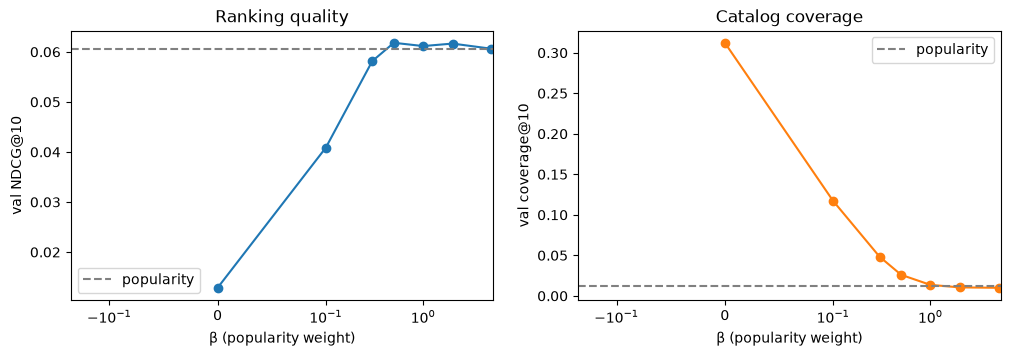

best β on val: 0.5


,beta,recall@10,ndcg@10,coverage@10,users
0,0.0,0.0131,0.0129,0.3123,567
1,0.1,0.0345,0.0409,0.1172,567
2,0.3,0.0573,0.0582,0.0483,567
3,0.5,0.0625,0.0618,0.0260,567
4,1.0,0.0652,0.0612,0.0135,567
5,2.0,0.0650,0.0617,0.0105,567
6,5.0,0.0634,0.0606,0.0100,567


In [12]:
betas = [0, 0.1, 0.3, 0.5, 1, 2, 5]
rows = []
for beta in betas:
    m = ContentModel(**best_content, popularity_weight=beta).fit(train, movies, tags_train)
    rows.append({"beta": beta, **evaluate(m, train, val)})
beta_grid = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(beta_grid["beta"], beta_grid["ndcg@10"], marker="o")
axes[0].axhline(pop_val["ndcg@10"], color="gray", linestyle="--", label="popularity")
axes[0].set(xlabel="β (popularity weight)", ylabel="val NDCG@10", title="Ranking quality")
axes[0].set_xscale("symlog", linthresh=0.1)
axes[0].legend()
axes[1].plot(beta_grid["beta"], beta_grid["coverage@10"], marker="o", color="tab:orange")
axes[1].axhline(pop_val["coverage@10"], color="gray", linestyle="--", label="popularity")
axes[1].set(xlabel="β (popularity weight)", ylabel="val coverage@10", title="Catalog coverage")
axes[1].set_xscale("symlog", linthresh=0.1)
axes[1].legend()
plt.show()

best_beta = float(beta_grid.loc[beta_grid["ndcg@10"].idxmax(), "beta"])
print(f"best β on val: {best_beta:g}")
beta_grid.round(4)

## 7. Final numbers on test

Refit on train + val. Tags now only need to exclude the test pairs. The bias model uses the NDCG-tuned settings from phase 1 (`reg_user=100, reg_item=200`); change them if your phase 1 run picked different ones.

In [13]:
history = pd.concat([train, val], ignore_index=True)
tags_history = drop_pairs(tags, test)

models = {
    "popularity": Popularity().fit(history),
    "bias (NDCG-tuned)": BiasModel(reg_user=100, reg_item=200).fit(history),
    "content": ContentModel(**best_content).fit(history, movies, tags_history),
    f"content + popularity (β={best_beta:g})": ContentModel(**best_content, popularity_weight=best_beta).fit(history, movies, tags_history),
}
results = {name: evaluate(m, history, test) for name, m in models.items()}
pd.DataFrame(results).T.drop(columns="rmse", errors="ignore").round(4)

,recall@10,ndcg@10,coverage@10,users
popularity,0.0439,0.0459,0.0126,573.0
bias (NDCG-tuned),0.0505,0.0502,0.0099,573.0
content,0.0096,0.0073,0.3007,573.0
content + popularity (β=0.5),0.0526,0.0520,0.0276,573.0


## 8. What content can do that the baselines can't

**Brand-new movies.** Popularity and the bias model know nothing about a movie with no ratings. Content only needs genres and tags:

In [14]:
final = models["content"]
unrated = movies[~movies["movieId"].isin(history["movieId"]) & movies["movieId"].isin(tags_history["movieId"])]
print(f"{(~movies['movieId'].isin(history['movieId'])).sum():,} movies have no ratings in history; "
      f"{len(unrated)} of them have tags")
new_movie = int(unrated["movieId"].iloc[0])
print(f"\nmovies similar to {titles[new_movie]!r} (0 ratings):")
with_titles(final.similar(new_movie, 6).round(3))

825 movies have no ratings in history; 19 of them have tags

movies similar to 'Innocents, The (1961)' (0 ratings):


,similarity,title,n_ratings
movieId,,,
2488,1.000,Peeping Tom (1960),3
7114,1.000,"Collector, The (1965)",1
3627,0.934,Carnival of Souls (1962),1
26116,0.934,"Hush... Hush, Sweet Charlotte (1964)",0
7245,0.934,Tormented (1960),1
50800,0.884,"Messengers, The (2007)",0


**Brand-new users, right away.** Rate a few movies and get a profile with no retraining. Edit `my_ratings` with movies you know (titles are matched by substring, so check the printed matches):

In [15]:
my_ratings = {
    "Matrix, The (1999)": 5,
    "Inception (2010)": 5,
    "Interstellar (2014)": 4.5,
    "Toy Story (1995)": 3,
    "Notebook, The (2004)": 1.5,
}
ME = 0  # MovieLens user ids start at 1
mine = pd.DataFrame({"userId": ME, "movieId": [find(t) for t in my_ratings], "rating": list(my_ratings.values()), "timestamp": 0})
print("matched:", ", ".join(titles[mine["movieId"]]))

with_me = pd.concat([history, mine])
display(ContentModel(**best_content).fit(with_me, movies, tags).taste(ME, 8))

side_by_side = {}
for beta in [0, best_beta]:
    you = ContentModel(**best_content, popularity_weight=beta).fit(with_me, movies, tags)
    side_by_side[f"β={beta:g}"] = titles[top_k(you, np.array([ME]), mine, 10)[0]].to_numpy()
pd.DataFrame(side_by_side, index=range(1, 11))

matched: Matrix, The (1999), Inception (2010), Interstellar (2014), Toy Story (1995), Notebook, The (2004)


,leans toward,+,leans away from,-
0,tag:sci-fi,1.14,tag:sad,-1.65
1,tag:philosophy,0.95,tag:romance,-1.59
2,tag:thought-provoking,0.71,tag:pixar,-0.69
3,tag:visually appealing,0.63,tag:fun,-0.40
4,tag:alternate universe,0.59,genre:Romance,-0.11
5,tag:post apocalyptic,0.55,genre:Drama,-0.06
6,tag:martial arts,0.52,decade:2000s,-0.04
7,tag:dreamlike,0.37,genre:Animation,-0.04


,β=0,β=0.5
1,Moon (2009),Star Wars: Episode IV - A New Hope (1977)
2,Final Fantasy: The Spirits Within (2001),Fight Club (1999)
3,Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku...,Pulp Fiction (1994)
4,The Butterfly Effect (2004),Terminator 2: Judgment Day (1991)
5,Donnie Darko (2001),Forrest Gump (1994)
6,Arrival (2016),"Silence of the Lambs, The (1991)"
7,Eye in the Sky (2016),"Shawshank Redemption, The (1994)"
8,Doctor Strange (2016),Star Wars: Episode V - The Empire Strikes Back...
9,Predator (1987),Schindler's List (1993)
10,Star Wars: Episode IV - A New Hope (1977),"Usual Suspects, The (1995)"


Compare the two columns. Pure content follows your five ratings closely but digs up obscure titles. With the β that scored best on val, popularity dominates. With only five ratings, the content part of the score is small next to `β × log(1 + n_ratings)`, which reaches about 2.8 at β = 0.5 for the most-rated movies. The metric prefers that, but it's a weak "personal" list. Try a β in between.

## Takeaways

Write your own answers to the six questions at the top. Some things to look for:

- **Content alone ranks poorly here.** Its top picks match each profile well but are mostly movies hardly anyone watches, and on MovieLens what people go on to like is heavily skewed toward well-known movies. This is a property of the data and the metric, not a bug.
- **Adding popularity makes it competitive, but not much better.** Check how big the gap to popularity is on test. Remember phase 1's note: differences under ~0.005 NDCG can be noise.
- **Genres, tags and decade don't encode quality.** Two movies with the same tokens get the same score whether they're classics or flops. Phase 3's collaborative filtering learns from *who rated what how highly*, which captures quality and taste patterns that no tag describes.
- **The real value is elsewhere:** explainable recommendations (`explain`, `taste`), a "similar movies" endpoint, and handling new movies and new users without retraining. Production systems often keep a content model for exactly these cases next to a collaborative one.

### Try next

- Set `min_tag_movies=1` (keep tags used on only one movie). Does anything change? Why?
- Change `decade_weight`. Should a 1995 movie really be "similar" to every other 1990s movie?
- Evaluate only on users with few training ratings (say, under 30). Does content + popularity do better relative to plain popularity there?